In [31]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
FILE_PATH = "data/output.csv"
df = pd.read_csv(FILE_PATH)

In [28]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,province,date,day,month,year,day_of_week,season,is_holiday
0,TXN_9687814,Coffee,2.0,3.5,7.0,Digital Wallet,In-store,2023-09-28,British Columbia,2023-09-28,28,9,2023,Thursday,fall,False
1,TXN_7668262,Donut,1.0,2.0,2.0,Digital Wallet,In-store,2023-11-27,British Columbia,2023-11-27,27,11,2023,Monday,fall,False
2,TXN_7321503,Tea,1.0,3.0,3.0,Credit Card,Takeaway,2023-09-15,British Columbia,2023-09-15,15,9,2023,Friday,fall,False
3,TXN_7075658,Coffee,4.0,3.5,14.0,Credit Card,In-store,2023-10-21,Manitoba,2023-10-21,21,10,2023,Saturday,fall,False
4,TXN_3811286,Salad,5.0,9.0,45.0,Credit Card,Takeaway,2023-10-04,Manitoba,2023-10-04,4,10,2023,Wednesday,fall,False


## Basic Analysis

In [29]:
# Total Revenue
print(df['total_spent'].sum())
# Total Transactions
print(df['transaction_id'].count())
# Avg num of transcations per day
print()
# Avg Transaction Spent
print(round(df['total_spent'].mean(), 2))
# Total Selling Item
products_sold = df[['item', 'quantity']].groupby('item')['quantity'].sum()
print(products_sold.idxmax(), products_sold.max()) # Total quantity per item then get max
# Peak Selling Month (in Revenue)
monthly_rev = df[['month', 'total_spent']].groupby('month')['total_spent'].sum()
print(monthly_rev.idxmax(), monthly_rev.max())
# Next Month Forecast
print('TBD')


68627.5
7932

8.65
Coffee 4366.0
6 6319.5
TBD


## Sales Trends

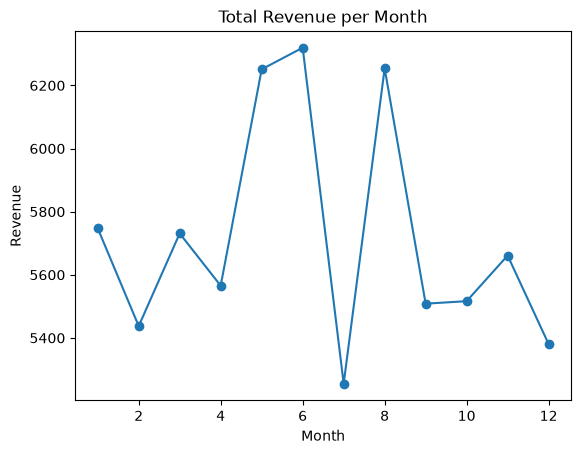

In [ ]:
rev_month = df.groupby("month")["total_spent"].sum()

rev_month.plot(kind="line", marker="o")
plt.title("Total Revenue per Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


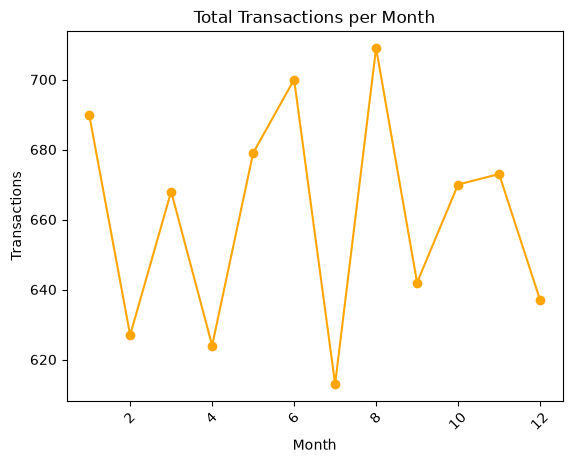

In [35]:

txn_month = df.groupby("month")["transaction_id"].count()

txn_month.plot(kind="line", marker="o", color="orange")
plt.title("Total Transactions per Month")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.show()


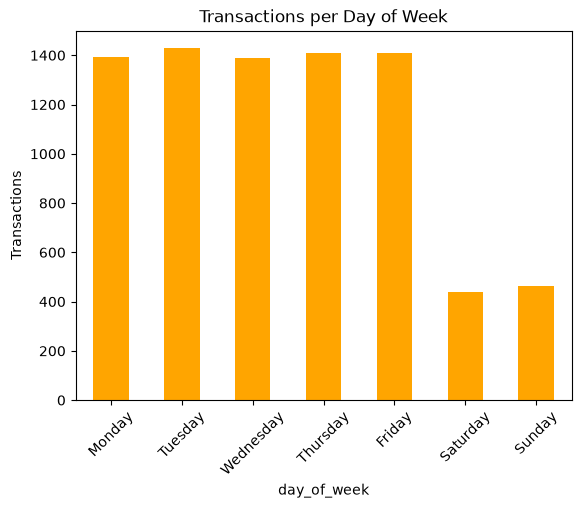

In [ ]:

txn_dow = df.groupby("day_of_week")["transaction_id"].count()
txn_dow = txn_dow.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

txn_dow.plot(kind="bar", color="orange")
plt.title("Transactions per Day of Week")
plt.ylabel("Transactions")
plt.xlabel("Day")
plt.xticks(rotation=45)
plt.show()


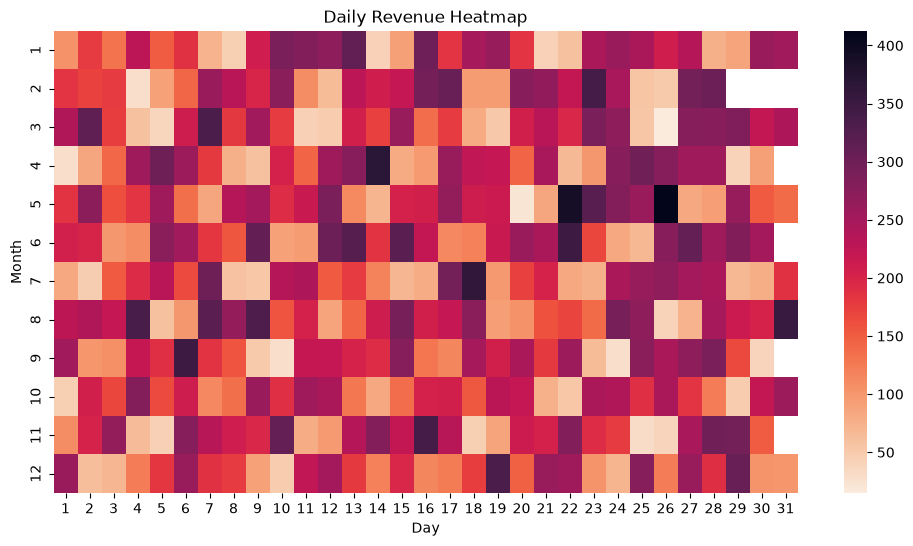

In [ ]:
# Might be best to skip this lol
heatmap_data = df.groupby(["month", "day"])["total_spent"].sum().unstack()

holiday_mask = df[df["is_holiday"]] # not sure how to use the mask

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='rocket_r')

plt.title("Daily Revenue Heatmap")
plt.xlabel("Day")
plt.ylabel("Month")
plt.show()

## Product Performance

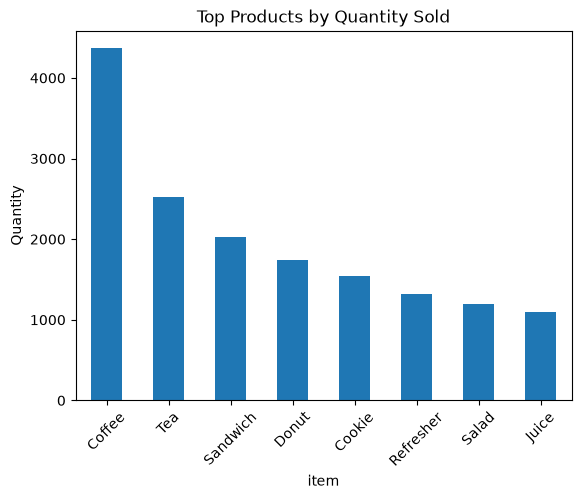

In [48]:
top_items = df.groupby("item")["quantity"].sum().sort_values(ascending=False)#.head(10)

top_items.plot(kind="bar")
plt.title("Top Products by Quantity Sold")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.show()

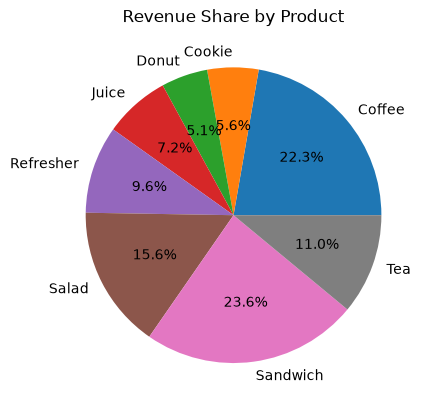

In [ ]:
rev_item = df.groupby("item")["total_spent"].sum()

rev_item.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue Share by Product")
plt.ylabel("")
plt.show()


## Location Insights

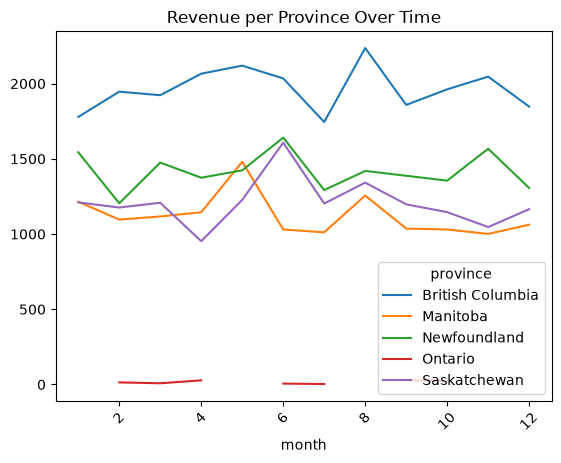

In [52]:
prov_month = df.groupby(["month", "province"])["total_spent"].sum().unstack()

prov_month.plot()
plt.title("Revenue per Province Over Time")
plt.xticks(rotation=45)
plt.show()

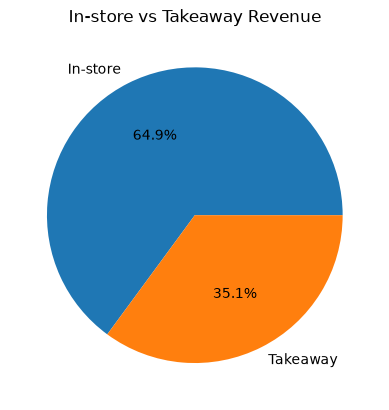

In [55]:
loc_split = df.groupby("location")["total_spent"].sum()

loc_split.plot(kind="pie", autopct="%1.1f%%")
plt.title("In-store vs Takeaway Revenue")
plt.ylabel("")
plt.show()

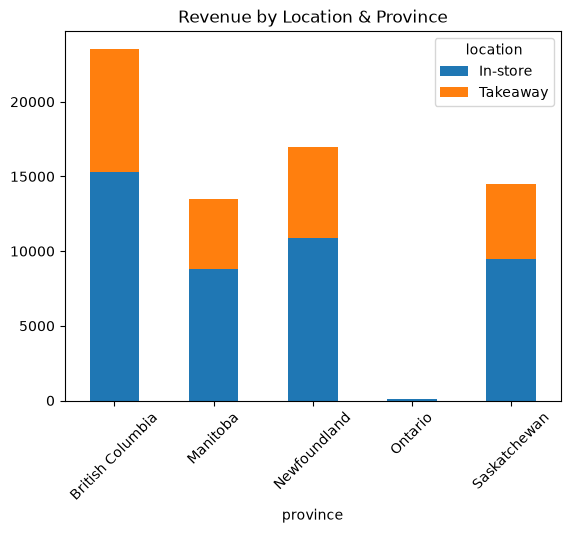

In [53]:
loc_prov = df.groupby(["province", "location"])["total_spent"].sum().unstack()

loc_prov.plot(kind="bar", stacked=True)
plt.title("Revenue by Location & Province")
plt.xticks(rotation=45)
plt.show()


## Payment Behaviour

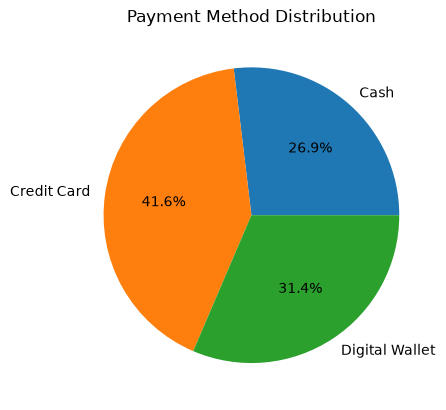

In [56]:

pay = df.groupby("payment_method")["total_spent"].sum()

pay.plot(kind="pie", autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()


## Advanced Metrics

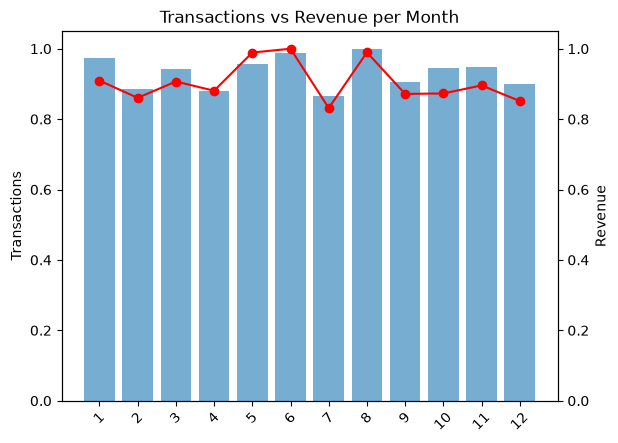

In [ ]:
# note: graphs dont scale well together should probably also skip
monthly = df.groupby("month").agg({
    "transaction_id": "count",
    "total_spent": "sum"
}).reset_index()

monthly["txn_norm"] = monthly["transaction_id"] / monthly["transaction_id"].max()
monthly["rev_norm"] = monthly["total_spent"] / monthly["total_spent"].max()

x = range(len(monthly))  # shared x positions

fig, ax1 = plt.subplots()

# Bars (transactions)
ax1.bar(x, monthly["txn_norm"], alpha=0.6)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Transactions")

# Line (revenue)
ax2 = ax1.twinx()
ax2.plot(x, monthly["rev_norm"], color="red", marker="o")
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Revenue")

# Fix x-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(monthly["month"], rotation=45)

plt.title("Normalized Transactions vs Revenue per Month")
plt.show()